# Corrected Statistical Analysis for KL-Constrained Baum-Welch

This notebook demonstrates evaluation of KL-BW vs standard BW.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')
_pip('loguru==0.7.2')


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json, numpy as np
from scipy import stats
from itertools import combinations
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-797861-robust-parameter-learning-under-hmm-orde/main/iter_0/gen_art_evaluation_1/demo/mini_demo_data.json"

def load_data():
    import os
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load data")

In [4]:
data = load_data()
N_BOOTSTRAP = 100
EPSILONS = [0.01, 0.05, 0.1, 0.5]
EPS_KEYS = ["predict_kl_eps_0_01", "predict_kl_eps_0_05", "predict_kl_eps_0_1", "predict_kl_eps_0_5"]
RNG = np.random.default_rng(42)
print(f'Loaded {len(data["datasets"][0]["examples"])} examples')

Loaded 3 examples


In [5]:
def parse_predict(s): return json.loads(s)
def bootstrap_ci(values, statistic=np.mean, n_boot=None, ci=0.95):
    if n_boot is None: n_boot = N_BOOTSTRAP
    boots = [statistic(RNG.choice(values, size=len(values), replace=True)) for _ in range(n_boot)]
    lo = (1 - ci) / 2
    return float(np.quantile(boots, lo)), float(np.quantile(boots, 1 - lo))
def cohens_d_paired(a, b):
    diff = a - b
    return float(diff.mean() / (diff.std(ddof=1) + 1e-12))

In [6]:
examples = data["datasets"][0]["examples"]
records = []
for ex in examples:
    bw = parse_predict(ex["predict_standard_bw"])
    kl_best = parse_predict(ex["predict_kl_best"])
    kl_by_eps = {eps: parse_predict(ex[key]) for eps, key in zip(EPSILONS, EPS_KEYS)}
    records.append({"k_true": int(ex["metadata_k_true"]), "T": int(ex["metadata_T"]), "seed": int(ex["metadata_seed"]), "bw_acc": float(bw["accuracy"]), "kl_acc_by_eps": {eps: float(kl_by_eps[eps]["accuracy"]) for eps in EPSILONS}})
print(f'Parsed {len(records)} records')

Parsed 3 records


In [7]:
table1 = {}
for k in [1, 2, 3]:
    subset = [r for r in records if r["k_true"] == k]
    if len(subset) == 0: continue
    bw_accs, kl_accs = np.array([r["bw_acc"] for r in subset]), np.array([r["kl_acc_by_eps"][0.01] for r in subset])
    diffs = (kl_accs - bw_accs) * 100
    pp_gain, ci_lo, ci_hi = float(diffs.mean()), *bootstrap_ci(diffs)
    table1[f"k_true_{k}"] = {"n": len(subset), "mean_bw_acc": float(bw_accs.mean()), "mean_kl_acc": float(kl_accs.mean()), "pp_gain": pp_gain, "ci_95": (ci_lo, ci_hi)}
for k in [1,2,3]:
    if f"k_true_{k}" in table1:
        v = table1[f"k_true_{k}"]
        print(f"k={k}: pp={v['pp_gain']:+.3f} [{v['ci_95'][0]:+.3f}, {v['ci_95'][1]:+.3f}]")

k=1: pp=-0.080 [-0.080, -0.080]
k=2: pp=-0.920 [-0.920, -0.920]
k=3: pp=+4.700 [+4.700, +4.700]


In [8]:
all_pp = [(r["kl_acc_by_eps"][0.01] - r["bw_acc"]) * 100 for r in records]
overall_mean_pp = float(np.mean(all_pp))
overall_bw = float(np.mean([r["bw_acc"] for r in records]))
overall_kl = float(np.mean([r["kl_acc_by_eps"][0.01] for r in records]))
print(f'Overall: BW={overall_bw:.4f}, KL={overall_kl:.4f}, pp_gain={overall_mean_pp:+.3f}')

Overall: BW=0.7025, KL=0.7149, pp_gain=+1.233


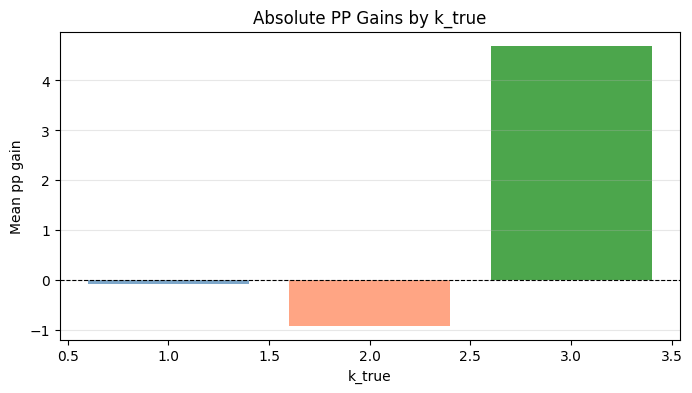

Visualization complete.


In [9]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
k_vals = [1, 2, 3]
gains = [table1.get(f"k_true_{k}", {}).get("pp_gain", 0) for k in k_vals]
ax.bar(k_vals, gains, color=['steelblue', 'coral', 'green'], alpha=0.7)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('k_true')
ax.set_ylabel('Mean pp gain')
ax.set_title('Absolute PP Gains by k_true')
ax.grid(axis='y', alpha=0.3)
plt.show()
print('Visualization complete.')